# P13 - Explainability SHAP

Analyse globale et locale des facteurs qui influencent les predictions de modeles.

In [1]:
import json
from pathlib import Path
import sys

import joblib
import pandas as pd
import plotly.express as px
import shap

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
    models_dir = Path('/app/models')
else:
    sys.path.insert(0, '../../src')
    models_dir = Path('../../models')

from p13.db import read_sql
from p13.ml.features import FEATURE_COLUMNS, ALL_FEATURE_COLUMNS


In [2]:
target = 'nb_eleves_elementaire'
model_path = models_dir / f'{target}_best.joblib'

if not model_path.exists():
    raise FileNotFoundError(f'Modele non trouve: {model_path}. Lancez /ml/train avant SHAP.')

model = joblib.load(model_path)

# Lire les features depuis le metadata JSON — garantit la cohérence avec le modèle sauvegardé
meta_path = models_dir / f'{target}_meta.json'
if meta_path.exists():
    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    model_features = meta.get('features', FEATURE_COLUMNS)
else:
    # Fallback : déduire depuis n_features_in_ du modèle
    from sklearn.pipeline import Pipeline as _Pipeline
    _inner = model.steps[-1][1] if isinstance(model, _Pipeline) else model
    n = getattr(_inner, 'n_features_in_', len(FEATURE_COLUMNS))
    model_features = ALL_FEATURE_COLUMNS if n == len(ALL_FEATURE_COLUMNS) else FEATURE_COLUMNS

print(f'Features utilisées ({len(model_features)}) : {model_features}')

df = read_sql('SELECT * FROM ml_dataset_commune ORDER BY rentree, code_insee')
df = df.dropna(subset=model_features + [target]).copy()
X = df[model_features]
X.shape


Features utilisées (9) : ['population', 'pop_0_14_pct', 'natalite', 'densite', 'log_collectif', 'log_individuel', 'plh_logements', 'nb_mutations', 'nb_permis_logements']


(688, 9)

## Calcul SHAP

**SHAP (SHapley Additive exPlanations)** mesure la contribution de chaque feature à chaque prédiction individuelle.

- La valeur SHAP d'une feature représente **de combien elle fait varier la prédiction** par rapport à la prédiction moyenne du modèle.
- Une valeur **positive** → la feature pousse la prédiction **à la hausse** (plus d'élèves estimés).
- Une valeur **négative** → la feature tire la prédiction **à la baisse**.
- La valeur absolue indique l'intensité de l'influence.

L'explainer est adapté automatiquement au type de modèle : TreeExplainer pour GradientBoosting/RandomForest (rapide), KernelExplainer en fallback (lent, modèle-agnostique).

In [3]:
sample_size = min(50, len(X))
X_sample = X.sample(sample_size, random_state=42) if len(X) > sample_size else X.copy()
X_sample_np = X_sample.to_numpy()

# PermutationExplainer : 100% Python, appelle uniquement model.predict()
# → pas de traversée d'arbres en C++, pas de crash kernel
# → compatible avec tout modèle sklearn (Pipeline inclus, GradientBoosting, RF, Linear...)
masker = shap.maskers.Independent(X_sample_np, max_samples=sample_size)
explainer = shap.PermutationExplainer(model.predict, masker)

# max_evals = 2×nb_features+1 = minimum requis (9 pour 4 features) — très rapide
shap_values = explainer(X_sample_np, max_evals=2 * X_sample_np.shape[1] + 1)

'SHAP calculé sur ' + str(len(X_sample_np)) + ' lignes'


'SHAP calculé sur 50 lignes'

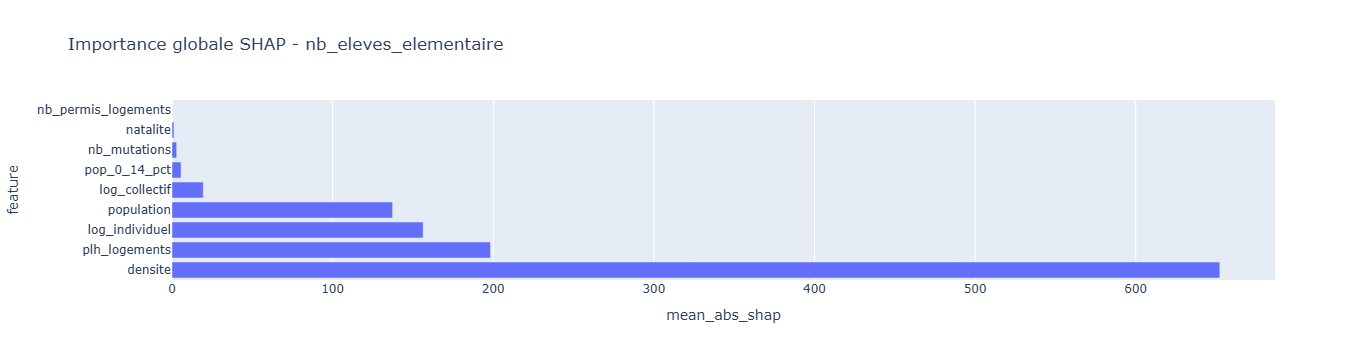

,feature,mean_abs_shap
3,densite,652.342069
6,plh_logements,198.277061
5,log_individuel,156.338873
0,population,137.361463
4,log_collectif,19.445491
1,pop_0_14_pct,5.628037
7,nb_mutations,2.908175
2,natalite,1.199918
8,nb_permis_logements,0.000000


In [4]:
if hasattr(shap_values, 'values'):
    values = shap_values.values
else:
    values = shap_values

importance = pd.DataFrame({
    'feature': model_features,
    'mean_abs_shap': pd.DataFrame(values, columns=model_features).abs().mean().values
}).sort_values('mean_abs_shap', ascending=False)

fig = px.bar(
    importance.head(15),
    x='mean_abs_shap',
    y='feature',
    orientation='h',
    title=f'Importance globale SHAP - {target}'
)
fig.show()
importance


## Importance globale des features

Le graphique ci-dessous montre la **moyenne des valeurs absolues SHAP** sur l'ensemble des observations : c'est une mesure d'importance **globale**.

| Feature | Lecture métier |
|---|---|
| `population` | Taille de la commune — driver principal des effectifs |
| `pop_0_14_pct` | Part des 0-14 ans — proxy direct de la population scolarisable |
| `natalite` | Renouvellement démographique à court terme |
| `densite` | Densité urbaine — corrélée à la concentration de familles |
| `log_collectif` / `log_individuel` | Type de parc logement — influence la composition familiale |
| `plh_logements` | Logements programmés au PLH — anticipe les flux futurs |
| `nb_mutations` | Dynamisme immobilier récent |
| `nb_permis_logements` | Offre neuve en construction |

> **Attention** : l'importance SHAP globale ne dit pas dans quelle direction une feature agit sur une commune spécifique. La cellule suivante apporte cette information locale.

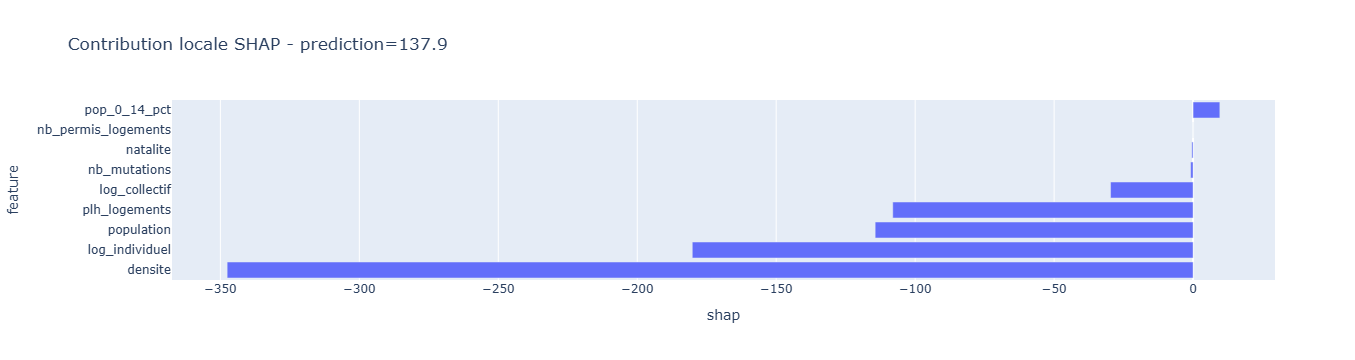

,feature,value,shap
3,densite,374.0,-347.564549
5,log_individuel,521.0,-180.201149
0,population,1793.0,-114.390986
6,plh_logements,102.0,-108.066255
4,log_collectif,13.0,-29.686941
7,nb_mutations,85.0,-0.869014
2,natalite,13.4,-0.444289
8,nb_permis_logements,0.0,0.000000
1,pop_0_14_pct,27.7,9.636653


In [5]:
idx = 0
row = X_sample.iloc[[idx]]
row_np = row.to_numpy()
pred = float(model.predict(row_np)[0])

local = pd.DataFrame({
    'feature': model_features,
    'value': row_np[0]
})

if hasattr(shap_values, 'values'):
    local['shap'] = shap_values.values[idx]
else:
    local['shap'] = values[idx]

local = local.sort_values('shap')
fig_local = px.bar(local, x='shap', y='feature', orientation='h', title=f'Contribution locale SHAP - prediction={pred:.1f}')
fig_local.show()
local


## Contribution locale (une observation)

Ce graphique montre comment chaque feature a contribué à la prédiction d'une **commune précise** (première ligne du jeu de test).

- Barres à droite (positives) → la feature **augmente** le nombre d'élèves prédit.
- Barres à gauche (négatives) → la feature **réduit** le nombre d'élèves prédit.
- La prédiction finale = valeur de base (moyenne du modèle) + somme de toutes les contributions SHAP.

Pour analyser d'autres communes, modifiez la variable `idx` dans la cellule précédente.